# Transcoder-based Explainability for InterveneEncoder

This notebook demonstrates a lightweight **explainability layer** for the bidirectional EMR encoder defined in `intervene_enc/transformer.py`.

Each encoder block contains a **SwiGLU MLP** of the form
$$\text{MLP}(x) = W_2 \,\bigl(x_{\text{val}} \odot \text{SiLU}(x_{\text{gate}})\bigr), \qquad [x_{\text{val}};\, x_{\text{gate}}] = W_1 x.$$
The non-linear gating makes the internals hard to read directly. We side-step this by training a **JumpReLU transcoder** per layer – a sparse dictionary learner that approximates the *input → output* map of the MLP through a high-dimensional but sparsely-active feature space:
$$\hat{y} \;=\; W_{\text{dec}}\,f(x) + b_{\text{dec}}, \qquad f(x) = \text{JumpReLU}(W_{\text{enc}} x + b_{\text{enc}};\, \theta).$$
Because we regress directly on the I/O pair, we never have to decompose the SwiGLU non-linearity.

What the notebook shows:
1. Capture MLP I/O activations from a frozen Phase-3 checkpoint.
2. Train one JumpReLU transcoder per layer (a few minutes on CPU for the M-128 model).
3. **Reconstruction fidelity** – MSE / explained-variance per layer.
4. **Sparsity** – L0 distribution across tokens; only a handful of features are active per token.
5. **Feature-firing heatmap** – which features fire across the patient timeline.
6. **Logit attribution** – for one (patient, outcome), which (layer, token, feature) triples drove the prediction.

*Goal: demonstrate the capability rigorously enough to be convincing, while staying small enough to run end-to-end in the notebook.*

In [1]:
import os, sys, math, copy
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# The notebook lives in `xai/`; project root is one level up.
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {DEVICE}')

device = cpu


## 1. Load the frozen encoder and a small dataloader

We rebuild the embedder + encoder exactly as the Phase-3 pipeline does and load the best Phase-3 checkpoint (with task heads). Everything from here on is read-only on the encoder.

In [2]:
from intervene_enc import (
    DataProcessor, EMRDataset, EMRTokenizer, get_dataloader,
    EMREmbedding, InterveneEncoder,
)
from intervene_enc.config.model_config import (
    MODEL_CONFIG, PHASE1_CHECKPOINT, PHASE3_CHECKPOINT,
)

# --- build embedder + encoder from config ---
tokenizer = EMRTokenizer.load()                      # uses default checkpoint dir
# Load the Phase-1 embedder from its own checkpoint -- this recovers ctx_dim
# / time2vec_dim / embed_dim from the saved config, so we don't have to
# guess the context-vector width.
embedder, *_ = EMREmbedding.load(PHASE1_CHECKPOINT, tokenizer=tokenizer,
                                 map_location=DEVICE)

# Load Phase-3 ckpt; task heads come along for attribution.
model, *_ = InterveneEncoder.load(
    PHASE3_CHECKPOINT, embedder=embedder, map_location=DEVICE,
    attach_task_heads=True,
)
model = model.to(DEVICE).eval()
for p in model.parameters():
    p.requires_grad_(False)
print(f'model loaded: {model.get_num_params()/1e6:.2f} M params, {len(model.blocks)} blocks, d={MODEL_CONFIG["embed_dim"]}')

[InterveneEncoder] Outcomes not in tokenizer vocab (ignored): ['ACUTE_RESPIRATORY_DISORDER_EVENT', 'DIABETIC_COMA_EVENT', 'INFECTION_EVENT', 'OTHER_COMPLICATION_EVENT']
[InterveneEncoder]: Total params: 1.68 M
model loaded: 1.84 M params, 4 blocks, d=128


In [3]:
from intervene_enc import collate_emr
import random, gc

# --- 1. Load source CSVs (aligned with the tak-repo + tokenizer the ckpt was trained on) ---
train_temporal = pd.read_csv(PROJECT_ROOT / 'data' / 'source' / 'temporal_data.csv')
train_ctx      = pd.read_csv(PROJECT_ROOT / 'data' / 'source' / 'context_data.csv')

# --- 2. Process + build the full dataset once so we can stratify on outcome membership ---
proc = DataProcessor(train_temporal, train_ctx,
                     tak_repo_path=str(PROJECT_ROOT / 'intervene_enc' / 'config' / 'tak-repo-portable.json'))
proc.run()
full_ds = EMRDataset(proc.df, proc.context_df, tokenizer)

# --- 3. Stratified patient subset --------------------------------------------- #
# Random N of 57k can starve outcomes with <1% prevalence.  Instead we guarantee
# `PER_OUTCOME_QUOTA` patients from each outcome's positive pool, then random-fill
# the rest up to `N_PATIENTS`.
N_PATIENTS        = 250          # lean budget -- peak now ~2-3 GB across the run.
PER_OUTCOME_QUOTA = 25           # patients pulled from each outcome's positives.

rng = random.Random(0)
outcome_names = list(model.outcome_names)

print('scanning patient timelines for outcome membership...')
pid_to_concepts = {pid: set(g['Concept'].values) for pid, g in full_ds.patient_groups.items()}
all_pids = list(full_ds.patient_ids)

selected = set()
for oc in outcome_names:
    pos_pids = [pid for pid, cs in pid_to_concepts.items() if oc in cs]
    take = min(PER_OUTCOME_QUOTA, len(pos_pids))
    if take == 0:
        print(f'  [warn] outcome "{oc}" has 0 positive patients in source data.')
        continue
    chosen = rng.sample(pos_pids, take)
    selected.update(chosen)
    print(f'  {oc:35s}  positives in source: {len(pos_pids):6d}  -> took {take}')

quota_n  = len(selected)
remaining = [p for p in all_pids if p not in selected]
fill_n   = max(0, N_PATIENTS - quota_n)
selected.update(rng.sample(remaining, min(fill_n, len(remaining))))
selected_list = list(selected)
print(f'final subset: {len(selected_list)} patients '
      f'({quota_n} from outcome quotas + {fill_n} random fill)')

# --- 4. Build the subset dataset, then free the heavy intermediates ----------- #
subset_tokens_df  = full_ds.tokens_df[full_ds.tokens_df['PatientId'].isin(selected_list)].copy()
subset_context_df = full_ds.context_df.loc[full_ds.context_df.index.isin(selected_list)].copy()
ds = EMRDataset(subset_tokens_df, subset_context_df, tokenizer)
dl = get_dataloader(ds, batch_size=8, collate_fn=collate_emr)
print(f'subset dataset: {len(ds)} patients, {len(dl)} batches at batch_size=8')

# Drop the multi-GB pre-subset structures -- we won't need them again.
del full_ds, pid_to_concepts, proc, train_temporal, train_ctx
gc.collect()
print('freed full dataset + raw dataframes.')

[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 18843972 -> 15640402
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 15640402 -> 14949783
[Warning][EMRDataset] Unknown PositionToken values found (count=15) — mapping to [MASK]:
  - M-SHR_MEASURE_STATE_Very High
  - PH_MEASURE_STATE_Mild Acidosis
  - PH_MEASURE_STATE_Severe Acidosis
  - GLUCOSE_MEASURE_STATE_Severe Hyperglycemia
  - BICARBONATE_MEASURE_STATE_Mild Acidosis
  - CREATINE-KINASE_MEASURE_STATE_Mild Elevation
  - ASPARATE-AMINOTRANSFERASE_MEASURE_STATE_Moderate Elevation
  - ALANINE-AMINOTRANSFERASE_MEASURE_STATE_Elevated
  - E-GFR_MEASURE_STATE_Moderate
  - SODIUM_MEASURE_STATE_Severe Hypernatremia
scanning patient timelines for outcome membership...
  DEATH_EVENT                          positives in source:   7247  -> took 25
  HYPERGLYCEMIA_EVENT                  positives in source:  21010  -> took 25
  HYPOGLYCEMIA_EVENT                   positives i

## 2. Capture MLP I/O activations

We register forward hooks on every `block.mlp` and run a handful of batches through the frozen encoder. Padded positions are filtered out so the transcoder never sees `[PAD]` rows.

In [4]:
from xai.transcoder.hooks import collect_activations

# Iterate the whole stratified subset (~500 patients, ~250k tokens). At 4 KB/token
# across 4 layers, activations ≈ 1 GB total -- safe on the current free RAM.
activations = collect_activations(
    model, dataloader=dl, device=DEVICE,
)
for i, (X, Y) in activations.items():
    print(f'layer {i}: X={tuple(X.shape)}  Y={tuple(Y.shape)}')

capture:   0%|          | 0/32 [00:00<?, ?it/s]

layer 0: X=(144710, 128)  Y=(144710, 128)
layer 1: X=(144710, 128)  Y=(144710, 128)
layer 2: X=(144710, 128)  Y=(144710, 128)
layer 3: X=(144710, 128)  Y=(144710, 128)


## 3. Train one transcoder per layer

* Dictionary expansion factor: **8×** d_model. With d=128 this gives 1024 features per layer – a reasonable starting point.
* Loss = MSE(reconstruction) + λ·L0(features), with JumpReLU's straight-through estimator on the threshold gate.
* Train for a few epochs on CPU/GPU; converges fast at this scale.

In [5]:
from xai.transcoder.train import train_transcoders, save_transcoders

D = MODEL_CONFIG['embed_dim']
EXPANSION = 4                    # 4× dictionary (512 features at d=128) -- halves §10 RAM.
N_FEATURES = EXPANSION * D

# Activations are cached; n_epochs costs no extra RAM, only wall-clock.
transcoders, hist = train_transcoders(
    activations,
    d_model=D, n_features=N_FEATURES,
    n_epochs=120, batch_size=4096,
    lr=3e-4, lambda_l0=2e-4, init_theta=0.05,
    device=str(DEVICE),
)
save_transcoders(transcoders, PROJECT_ROOT / 'checkpoints' / 'transcoders.pt')
print('done.')


=== Transcoder 1/4 — encoder layer 0 (X=(144710, 128), n_features=512) ===


layer0 ep1/120:   0%|          | 0/36 [00:00<?, ?it/s]

  [layer0] epoch   1/120  mse=1.3180e+01  L0= 137.5


layer0 ep2/120:   0%|          | 0/36 [00:00<?, ?it/s]

  [layer0] epoch   2/120  mse=1.0171e+01  L0= 111.8


...

  [layer3] epoch 118/120  mse=2.0371e+00  L0= 102.6


layer3 ep119/120:   0%|          | 0/36 [00:00<?, ?it/s]

  [layer3] epoch 119/120  mse=2.0322e+00  L0= 102.4


layer3 ep120/120:   0%|          | 0/36 [00:00<?, ?it/s]

  [layer3] epoch 120/120  mse=2.0240e+00  L0= 102.1
  -> done  final mse=2.0240e+00  final L0=102.1
done.


### Training curves
MSE should fall steadily; L0 (mean features active per token) should decay toward a small fraction of `n_features`.

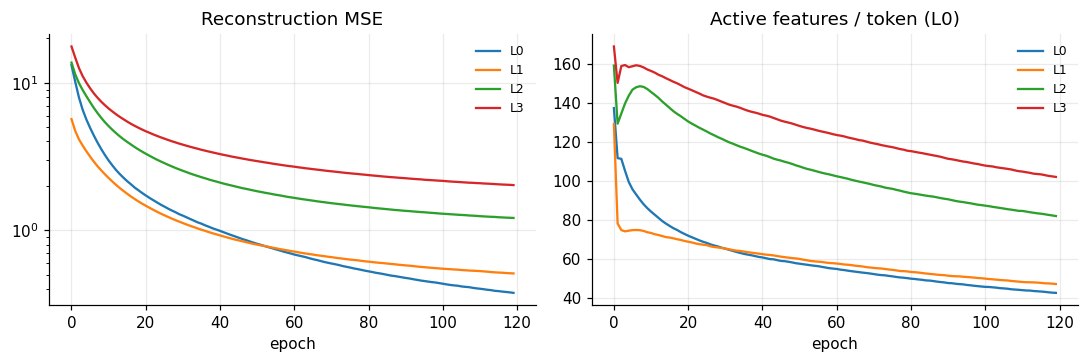

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for i, h in hist.items():
    axes[0].plot(h['mse'], label=f'L{i}')
    axes[1].plot(h['l0'],  label=f'L{i}')
axes[0].set_title('Reconstruction MSE'); axes[0].set_xlabel('epoch'); axes[0].set_yscale('log')
axes[1].set_title('Active features / token (L0)'); axes[1].set_xlabel('epoch')
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Reconstruction fidelity

**Explained variance** (R²) of the transcoder reconstruction vs. the real MLP output, per layer. If the bars sit near 1, the sparse approximation is faithful and any conclusion drawn through the transcoder is a conclusion about the real model.

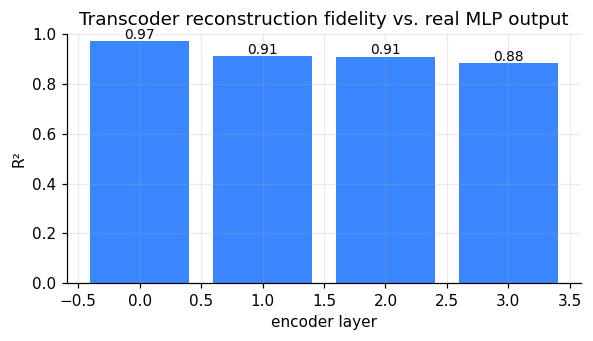

In [7]:
@torch.no_grad()
def explained_variance(tc, X, Y, batch=8192):
    """R^2 = 1 - var(Y - Y_hat) / var(Y), micro-averaged over coordinates."""
    ss_res = 0.0; ss_tot = 0.0
    y_mean = Y.mean(0, keepdim=True)
    for s in range(0, X.shape[0], batch):
        xb = X[s:s+batch].to(DEVICE); yb = Y[s:s+batch].to(DEVICE)
        _, yh = tc(xb)
        ss_res += ((yb - yh) ** 2).sum().item()
        ss_tot += ((yb - y_mean.to(DEVICE)) ** 2).sum().item()
    return 1.0 - ss_res / ss_tot

r2 = {i: explained_variance(transcoders[i], *activations[i]) for i in transcoders}

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(list(r2.keys()), list(r2.values()), color='#3a86ff')
ax.set_ylim(0, 1); ax.set_ylabel('R²'); ax.set_xlabel('encoder layer')
ax.set_title('Transcoder reconstruction fidelity vs. real MLP output')
for i, v in r2.items():
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Sparsity: how many features fire per token?

A useful sparse code has *many* features that are dormant on any given token and only a handful that fire. The per-token L0 distribution should sit far below the dictionary size.

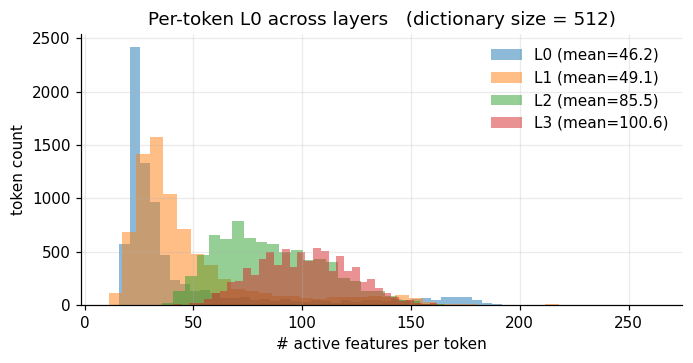

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, tc in transcoders.items():
    X, _ = activations[i]
    with torch.no_grad():
        f = tc.encode(X[:8000].to(DEVICE))
    l0_per_tok = (f > 0).sum(dim=-1).cpu().numpy()
    ax.hist(l0_per_tok, bins=40, alpha=0.5, label=f'L{i} (mean={l0_per_tok.mean():.1f})')
ax.set_xlabel('# active features per token'); ax.set_ylabel('token count')
ax.set_title(f'Per-token L0 across layers   (dictionary size = {N_FEATURES})')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [10]:
# Free the cached (X, Y) activations -- they were only needed for §2-5.
# After this point we re-derive features on the fly through hooks, one layer
# at a time, so holding the dense activations is just dead weight.
import gc
del activations
gc.collect()
print('activations freed.')

activations freed.


## 6. Downstream fidelity: do the predictions survive the transcoder swap?

Compare the model's risk logits with vs. without the transcoder swap-in. Logits on the diagonal means the swapped model behaves like the real one — and the SHAP-style per-outcome attribution below is therefore explaining the *real* prediction, not a degraded surrogate.

--- predicting WITHOUT swap (baseline) ---


predict[real]:   0%|          | 0/32 [00:00<?, ?it/s]

--- predicting WITH transcoder swap-in ---


predict[swap]:   0%|          | 0/32 [00:00<?, ?it/s]

collected: real=(250, 6)  swap=(250, 6)


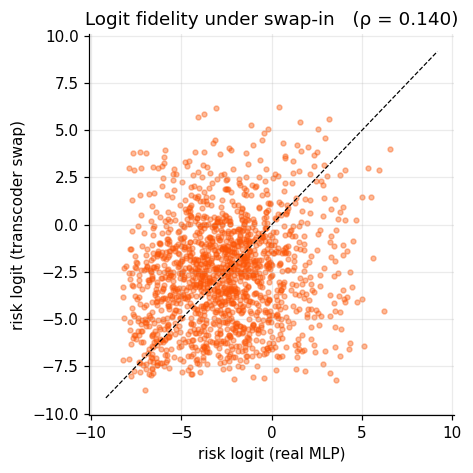

In [12]:
from xai import TranscoderHookManager
from tqdm.auto import tqdm

@torch.no_grad()
def predict_with_swap(model, transcoders, dl, swap=True):
    """Iterate the (subset) dataloader twice — once with swap on, once without."""
    mgr = TranscoderHookManager(model, transcoders, enabled=swap).attach()
    outs = []
    label = 'swap' if swap else 'real'
    try:
        for b in tqdm(dl, desc=f'predict[{label}]', leave=False):
            b = {k: v.to(DEVICE) for k, v in b.items()}
            risk, *_ = model.predict(**{k: b[k] for k in ['parent_raw_ids','concept_ids','value_ids','position_ids','abs_ts','context_vec']})
            outs.append(risk.cpu())
    finally:
        mgr.detach()
    return torch.cat(outs, dim=0)

print('--- predicting WITHOUT swap (baseline) ---')
risk_real = predict_with_swap(model, transcoders, dl, swap=False)
print('--- predicting WITH transcoder swap-in ---')
risk_swap = predict_with_swap(model, transcoders, dl, swap=True)
print(f'collected: real={tuple(risk_real.shape)}  swap={tuple(risk_swap.shape)}')

fig, ax = plt.subplots(figsize=(4.4, 4.4))
lim = max(risk_real.abs().max().item(), risk_swap.abs().max().item()) * 1.05
ax.scatter(risk_real.flatten(), risk_swap.flatten(), s=10, alpha=0.4, color='#fb5607')
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
ax.set_xlabel('risk logit (real MLP)'); ax.set_ylabel('risk logit (transcoder swap)')
corr = np.corrcoef(risk_real.flatten(), risk_swap.flatten())[0, 1]
ax.set_title(f'Logit fidelity under swap-in   (ρ = {corr:.3f})')
plt.tight_layout(); plt.show()

## 7. SHAP-style per-token drivers, one panel per outcome

For each risk outcome, aggregate the **signed contribution every concept-value token made to the outcome's logit** across many patients. Red bars are tokens that push risk *up*; blue bars push it *down*. `_START` / `_END` suffixes are collapsed so interval boundaries don't get split across two bars; `[NULL]` and `ADMISSION_EVENT` are filtered out (no semantic content).

Will explain 6 outcomes: ['DEATH_EVENT', 'HYPERGLYCEMIA_EVENT', 'HYPOGLYCEMIA_EVENT', 'KIDNEY_COMPLICATION_EVENT', 'SEVERE_HYPERGLYCEMIA_EVENT', 'SEVERE_HYPOGLYCEMIA_EVENT']
Scanning 60 patients...


patients:   0%|          | 0/60 [00:00<?, ?it/s]

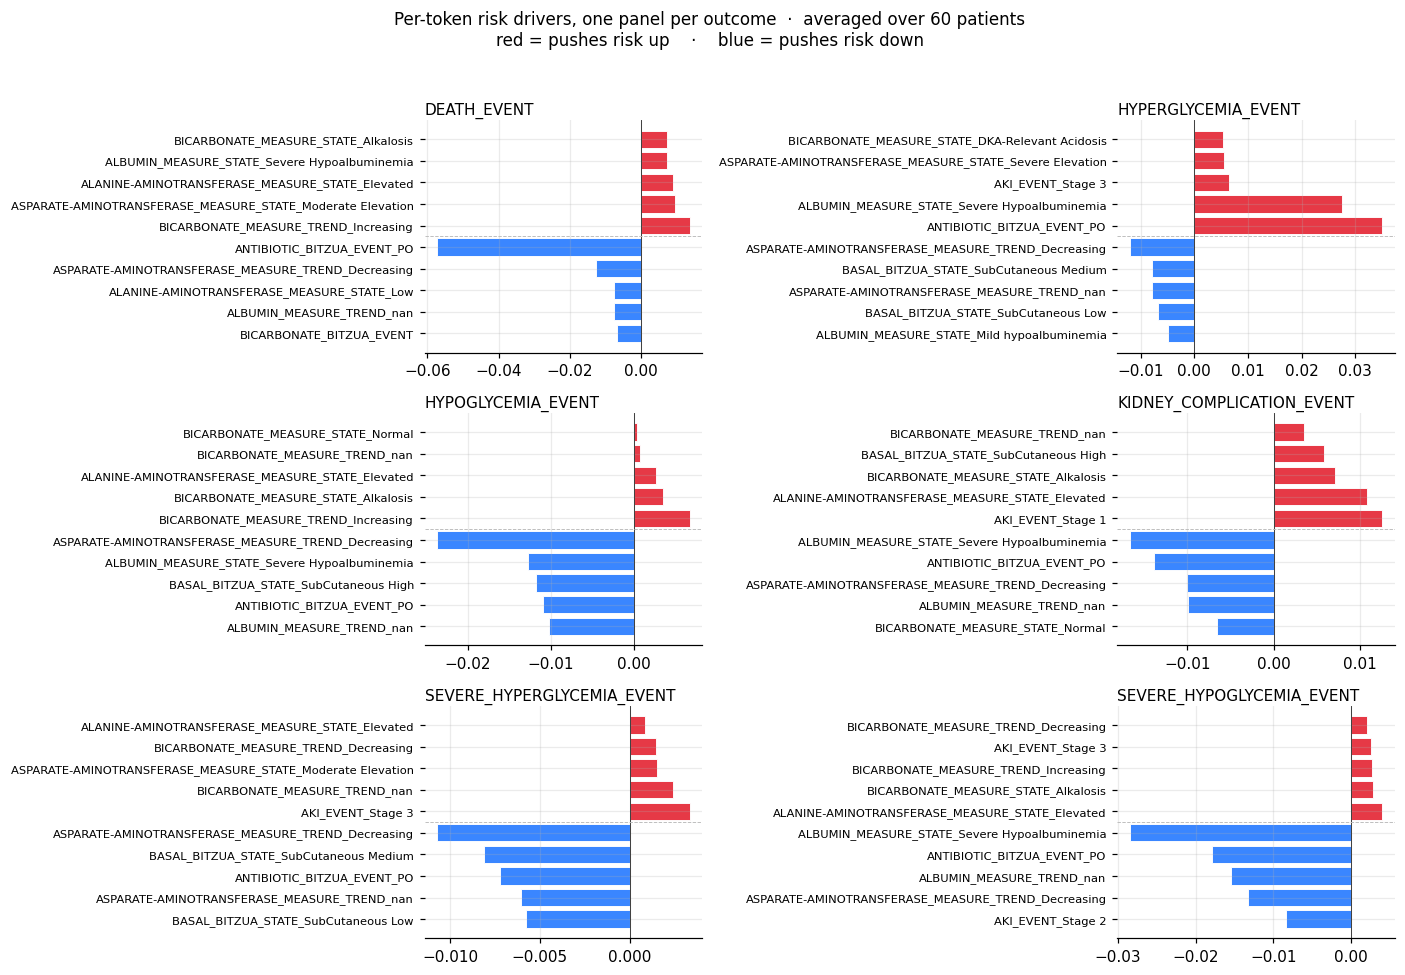

In [29]:
import re
from collections import defaultdict
from xai.attribute import TranscoderHookManager
from xai import feature_to_logit_attribution

# ----------------------------- knobs --------------------------------------- #
N_PATIENTS_SCAN  = 60       # one forward + K backwards per patient
TOP_K_PER_SIDE   = 5        # cap per side (we show fewer if fewer real drivers exist)
MIN_FIRINGS      = 3        # drop tokens seen < this many times
EXCLUDE_TOKENS   = {'[NULL]', 'ADMISSION_EVENT'}  # add canonical names to skip

# ---------------------- fix id2concept (BUGFIX) ---------------------------- #
# tokenizer.id2token is already a Dict[int, str]; previous code used
# `enumerate(dict)` which iterates keys, so we mapped 0->0, 1->1 ... and
# every label fell back to the `id=N` fallback.
id2concept = dict(model.embedder.tokenizer.id2token)

_SE_RE = re.compile(r'_(START|END)$')
def canon_token(name):
    if name is None: return '[NULL]'
    return _SE_RE.sub('', str(name))
id2canon = {cid: canon_token(name) for cid, name in id2concept.items()}

risk_idx_cpu  = model.task_heads.risk_idx.cpu().tolist()
risk_outcomes = [model.outcome_names[i] for i in risk_idx_cpu]
print(f'Will explain {len(risk_outcomes)} outcomes: {risk_outcomes}')

# per_outcome_agg[oc_name] -> { canonical_token: [sum_signed_attrib, n_fires] }
per_outcome_agg = {oc: defaultdict(lambda: [0.0, 0]) for oc in risk_outcomes}


def attribute_all_outcomes(batch, patient_idx):
    '''One forward + K backward passes, sharing the encoder graph via retain_graph.'''
    prev_ckpt = getattr(model, 'use_checkpoint', False)
    model.use_checkpoint = False
    mgr = TranscoderHookManager(model, transcoders, enabled=True).attach(track_grad=True)
    try:
        risk_logits, _, _, pad_mask = model.predict(
            parent_raw_ids=batch['parent_raw_ids'],
            concept_ids=batch['concept_ids'],
            value_ids=batch['value_ids'],
            position_ids=batch['position_ids'],
            abs_ts=batch['abs_ts'],
            context_vec=batch['context_vec'],
        )
        leaves   = list(mgr.features.values())
        layer_ks = list(mgr.features.keys())
        pad_p    = pad_mask[patient_idx].detach().cpu()
        out      = []
        K = len(risk_outcomes)
        for oc_idx, oc_name in enumerate(risk_outcomes):
            target = risk_logits[patient_idx, oc_idx]
            grads = torch.autograd.grad(
                target, leaves,
                retain_graph=(oc_idx < K - 1),
                allow_unused=False,
            )
            # per-token signed contribution = sum over (layer, feature) of f*grad
            per_tok = None
            for f, g in zip(leaves, grads):
                contrib = (f[patient_idx] * g[patient_idx]).detach().sum(dim=-1)  # [T]
                per_tok = contrib if per_tok is None else per_tok + contrib
            out.append((oc_name, per_tok.cpu(), pad_p))
        return out
    finally:
        mgr.detach()
        model.use_checkpoint = prev_ckpt


# ------------------------ scan + aggregate --------------------------------- #
print(f'Scanning {N_PATIENTS_SCAN} patients...')
pid_seen = 0
batch_iter = iter(dl)
pbar = tqdm(total=N_PATIENTS_SCAN, desc='patients', leave=False)
while pid_seen < N_PATIENTS_SCAN:
    try:
        batch = next(batch_iter)
    except StopIteration:
        batch_iter = iter(dl); batch = next(batch_iter)
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    B = batch['concept_ids'].size(0)
    for p in range(B):
        if pid_seen >= N_PATIENTS_SCAN: break
        results = attribute_all_outcomes(batch, p)
        cids = batch['concept_ids'][p].cpu().tolist()
        for oc_name, per_tok, pad_p in results:
            agg = per_outcome_agg[oc_name]
            for t, keep in enumerate(pad_p.tolist()):
                if not keep: continue
                name = id2canon.get(cids[t], f'id={cids[t]}')
                agg[name][0] += float(per_tok[t].item())
                agg[name][1] += 1
        pid_seen += 1; pbar.update(1)
pbar.close()

# --------------------------- grid plot ------------------------------------- #
n_oc  = len(risk_outcomes)
ncols = 2
nrows = (n_oc + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 1.6 * (2 * TOP_K_PER_SIDE) * 0.5 + 1))
axes = np.atleast_2d(axes).ravel()

for ax, oc_name in zip(axes, risk_outcomes):
    agg = per_outcome_agg[oc_name]
    rows_all = [
        (name, total / n, n)
        for name, (total, n) in agg.items()
        if n >= MIN_FIRINGS and name not in EXCLUDE_TOKENS
    ]
    # Up-to-K bars per side -- only count real positive / negative drivers.
    pos = [r for r in sorted(rows_all, key=lambda r: -r[1]) if r[1] > 0][:TOP_K_PER_SIDE]
    neg = [r for r in sorted(rows_all, key=lambda r:  r[1]) if r[1] < 0][:TOP_K_PER_SIDE]
    combined = pos[::-1] + neg
    if not combined:
        ax.set_title(oc_name + '  (no signal)', fontsize=9.5, loc='left')
        ax.set_visible(True); ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        continue
    labels = [r[0] for r in combined]
    means  = np.array([r[1] for r in combined])
    counts = [r[2] for r in combined]
    colors = ['#e63946' if m > 0 else '#3a86ff' for m in means]
    y = np.arange(len(labels))
    ax.barh(y, means, color=colors, edgecolor='white', linewidth=0.6)
    ax.axvline(0, color='#333', lw=0.6)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7.5)
    ax.invert_yaxis()
    ax.spines['left'].set_visible(False); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.25)
    ax.set_title(oc_name, fontsize=10, loc='left', pad=4)
    ax.axhline(len(pos) - 0.5, color='#bbb', lw=0.6, linestyle='--')

for ax in axes[n_oc:]:
    ax.set_visible(False)

fig.suptitle(f'Per-token risk drivers, one panel per outcome  ·  averaged over {pid_seen} patients\n'
             'red = pushes risk up    ·    blue = pushes risk down',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
